<a href="https://colab.research.google.com/github/oyrslufe/ESAA/blob/main/YB%204%EC%A1%B0%20%EB%AF%B8%EB%8B%88%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B8(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#회귀를 이용한 영화 관객수 예측

##1. 데이터 불러오기 및 확인

In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies_test.csv to movies_test (1).csv
Saving movies_train.csv to movies_train (1).csv
Saving submission.csv to submission (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('movies_train (1).csv')
test = pd.read_csv('movies_test (1).csv')
submission = pd.read_csv('submission (1).csv')

In [4]:
print(train.shape)
print(test.shape)
print(submission.shape)

(600, 12)
(243, 11)
(243, 2)


In [5]:
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [6]:
test.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor
0,용서는 없다,시네마서비스,느와르,2010-01-07,125,청소년 관람불가,김형준,3.005290e+05,2,304,3
1,아빠가 여자를 좋아해,(주)쇼박스,멜로/로맨스,2010-01-14,113,12세 관람가,이광재,3.427002e+05,4,275,3
2,하모니,CJ 엔터테인먼트,드라마,2010-01-28,115,12세 관람가,강대규,4.206611e+06,3,419,7
3,의형제,(주)쇼박스,액션,2010-02-04,116,15세 관람가,장훈,6.913420e+05,2,408,2
4,평행 이론,CJ 엔터테인먼트,공포,2010-02-18,110,15세 관람가,권호영,3.173800e+04,1,380,1


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           243 non-null    object 
 1   distributor     243 non-null    object 
 2   genre           243 non-null    object 
 3   release_time    243 non-null    object 
 4   time            243 non-null    int64  
 5   screening_rat   243 non-null    object 
 6   director        243 non-null    object 
 7   dir_prev_bfnum  107 non-null    float64
 8   dir_prev_num    243 non-null    int64  
 9   num_staff       243 non-null    int64  
 10  num_actor       243 non-null    int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 21.0+ KB


In [9]:
train.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,2.700000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,1.050443e+06,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.791408e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,2.038000e+04,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,1.286569e+06,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


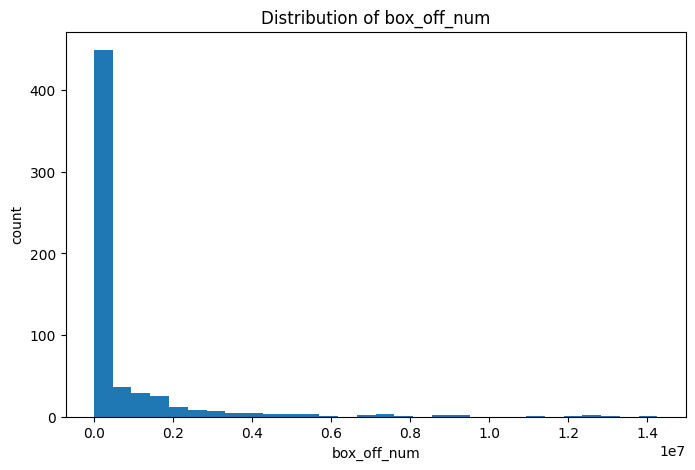

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(train['box_off_num'], bins=30)
plt.title('Distribution of box_off_num')
plt.xlabel('box_off_num')
plt.ylabel('count')
plt.show()

곽객수 데이터가 한쪽으로 크게 치우쳐져있다.

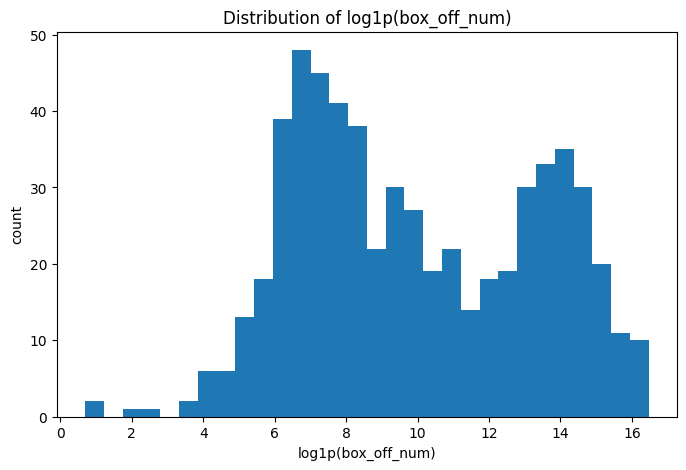

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train['box_off_num']), bins=30)
plt.title('Distribution of log1p(box_off_num)')
plt.xlabel('log1p(box_off_num)')
plt.ylabel('count')
plt.show()

관객 수 데이터는 일부 흥행작에 의해 오른쪽으로 치우친 분포를 보였기 때문에 로그 변환을 적용하여 분포를 완화하였다.

##2. 전처리

### (1) 결측치 확인 및 처리

In [12]:
train.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [13]:
test.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,136
dir_prev_num,0
num_staff,0


결측치 확인 결과, 감독의 이전 작품 평균 관객 수를 의미하는 dir_prev_bfnum 변수에서 결측치가 발견되었다. 이는 이전 작품 정보가 없는 감독의 경우로 해석할 수 있으므로 전처리 과정에서 0으로 처리하면 된다.

In [14]:
#train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
#test['dir_prev_bfnum'] = test['dir_prev_bfnum'].fillna(0)

In [15]:
train.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [16]:
test.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,136
dir_prev_num,0
num_staff,0


결측치를 0으로 대체하여 결측치가 사라진 것을 확인할 수 있다.

In [17]:
import numpy as np
import pandas as pd

# 날짜 가공 및 연도/월 피처 생성
train['release_time'] = pd.to_datetime(train['release_time'])
test['release_time'] = pd.to_datetime(test['release_time'])

train['release_year'] = train['release_time'].dt.year
test['release_year'] = test['release_time'].dt.year
train['release_month'] = train['release_time'].dt.month
test['release_month'] = test['release_time'].dt.month

# 영화 관객 성수기 피처 (7, 8, 12, 1월은 1, 나머지는 0)
train['is_season'] = train['release_month'].apply(lambda x: 1 if x in [7, 8, 12, 1] else 0)
test['is_season'] = test['release_month'].apply(lambda x: 1 if x in [7, 8, 12, 1] else 0)

# 타겟값(정답지) 로그 변환 - 명확하게 하나의 변수로 고정
y_final_log = np.log1p(train['box_off_num'])

# 5대 메이저 배급사 파생변수
major_distributors = ['CJE&M Movie', '롯데엔터테인먼트', '쇼박스', 'NEW', '메가박스']
train['is_major'] = train['distributor'].apply(lambda x: 1 if x in major_distributors else 0)
test['is_major'] = test['distributor'].apply(lambda x: 1 if x in major_distributors else 0)

# 수치형 피처 결측치 채우기 및 로그 변환
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
test['dir_prev_bfnum'] = test['dir_prev_bfnum'].fillna(0)

train['num_staff_log'] = np.log1p(train['num_staff'])
test['num_staff_log'] = np.log1p(test['num_staff'])
train['dir_prev_bfnum_log'] = np.log1p(train['dir_prev_bfnum'])
test['dir_prev_bfnum_log'] = np.log1p(test['dir_prev_bfnum'])

# train과 test 모두 수치형 원본 스태프 수 기준으로 동기화
train['staff_per_actor'] = train['num_staff'] / (train['num_actor'] + 1)
test['staff_per_actor'] = test['num_staff'] / (test['num_actor'] + 1)

# 불필요 원본 컬럼 및 중복 라벨 인코딩 변수 드롭
drop_cols = ['box_off_num', 'title', 'release_time', 'distributor', 'director', 'num_staff', 'dir_prev_bfnum', 'genre_le', 'screening_rat_le']
X_clean = train.drop(columns=drop_cols, errors='ignore')
X_test_clean = test.drop(columns=drop_cols, errors='ignore')

# 원-핫 인코딩 안전 수행
oh_cols = ['genre', 'screening_rat']
full_df = pd.concat([X_clean, X_test_clean], axis=0)
full_encoded_df = pd.get_dummies(full_df, columns=oh_cols, drop_first=True)

# 최종 학습/테스트 데이터셋 분리
X_final_encoded = full_encoded_df.iloc[:len(X_clean), :]
test_final_encoded = full_encoded_df.iloc[len(X_clean):, :]

print("학습 차원: {} | 테스트 차원: {}".format(X_final_encoded.shape, test_final_encoded.shape))

학습 차원: (600, 24) | 테스트 차원: (243, 24)


###`release_time`에서 연도, 월, 일 파생변수 생성

In [18]:
#release_time 날짜형으로 변환
#train['release_time'] = pd.to_datetime(train['release_time'])
#test['release_time'] = pd.to_datetime(test['release_time'])

In [19]:
#연도, 월, 일 파생변수 생성
#train['release_year'] = train['release_time'].dt.year
#train['release_month'] = train['release_time'].dt.month
#train['release_day'] = train['release_time'].dt.day

#test['release_year'] = test['release_time'].dt.year
#test['release_month'] = test['release_time'].dt.month
#test['release_day'] = test['release_time'].dt.day

In [20]:
#train[['release_time', 'release_year', 'release_month', 'release_day']].head()

In [21]:
#test[['release_time', 'release_year', 'release_month', 'release_day']].head()

`release_time`은 문자열 형태의 날짜 데이터였기 때문에 회귀 모델에 바로 사용하기 어렵다. 따라서 날짜형으로 변환한 뒤, 개봉 연도, 개봉 월, 개봉 일 변수를 새롭게 생성하였다. 영화의 개봉 시기는 방학, 명절, 성수기 등과 관련되어 관객 수에 영향을 줄 수 있으므로 파생변수로 활용하였다.

## realse time 제거

In [22]:
#train = train.drop(['release_year'], axis=1)
#test = test.drop(['release_year'], axis=1)

###(2) 배급사명 통일

In [23]:
#print(sorted(train['distributor'].unique()))
#print(sorted(test['distributor'].unique()))

In [24]:
#train['distributor'].value_counts()

In [25]:
#test['distributor'].value_counts()

동일 배급사에 대해 같은 키워드가 들어가는데 표현이 다를 경우 배급사명을 통일한다.

step1) 키워드 기반 일괄 통합 함수 정의

In [26]:
#def simplify_distributor(name):
#    if pd.isna(name):
#         return name

    # 텍스트 앞뒤의 의미 없는 공백 제거
#    name = str(name).strip()

    # 핵심 키워드가 포함되어 있으면 대표명으로 1차 변환
#   if "CGV" in name or "무비꼴라쥬" in name:
#        return "CGV아트하우스"
#    elif "쇼박스" in name:
#        return "쇼박스"
#    elif "싸이더스" in name:
#        return "싸이더스FNH"
#    elif "NEW" in name:
#        return "NEW"
#    elif "리틀빅" in name:
#        return "리틀빅픽처스"
#    elif "시네마달" in name or "시네마 달" in name:
#        return "시네마달"
#    elif "스폰지" in name:
#        return "스폰지이엔티"
#    elif "롯데" in name:
#        return "롯데엔터테인먼트"
#    elif "SK" in name:
#        return "SK"
#    elif "마운틴" in name:
#        return "마운틴픽쳐스"
#    elif "드림팩트" in name:
#        return "드림팩트엔터테인먼트"
#    elif "에이원" in name:
#        return "에이원엔터테인먼트"
#    else:
#        return name

step2) 글자가 아예 다른 계열사 및 특수 케이스 딕셔너리 정의
- 키워드 포함 검사로 걸러내지 못하는 대상을 최종 매핑

In [27]:
# dist_map = {
    # CJ 계열 통합
#    'CJ 엔터테인먼트': 'CJE&M Movie',
#    'CJ E&M 영화부문': 'CJE&M Movie',
#    'CJ E&M Pictures': 'CJE&M Movie',

    # 합병 및 계열사 관계 매핑
#    '메가박스(주)플러스엠': '메가박스',
#    '씨너스엔터테인먼트(주)': '메가박스',
#    '콘텐츠판다': 'NEW',

    # 조이앤시네마 통합
#    '조이앤컨텐츠그룹': '조이앤시네마',
#    '스크린조이': '조이앤시네마',
#    '(주) 케이알씨지': '조이앤시네마',

    # 기타
#    '사람과 사람들': '키노아이DMC',
#    '(주)키노아이': '키노아이DMC',
#    '(주)JK필름': '롯데엔터테인먼트',
#    '(주)이스트스카이필름': '롯데엔터테인먼트'
#}

step3) train 및 test 데이터셋에 적용

In [28]:
#for df in [train, test]:
    # 키워드 중심
#    df['distributor'] = df['distributor'].apply(simplify_distributor)

    # 계열사 및 잔여
#    df['distributor'] = df['distributor'].replace(dist_map)

step4) 결과 검증 및 확인

In [29]:
#print("==== Train 데이터 배급사====")
#print(train['distributor'].value_counts().head(10))

#print("\n==== Test 데이터 배급사====")
#print(test['distributor'].value_counts().head(10))

### (3) 이상치 로그변환

In [30]:
#이상치 확인

#Q1 = train['box_off_num'].quantile(0.25)
#Q3 = train['box_off_num'].quantile(0.75)
#IQR = Q3 - Q1

#lower = Q1 - 1.5*IQR
#upper = Q3 + 1.5*IQR

#outliers = train[(train['box_off_num'] < lower) | (train['box_off_num'] > upper)]
#out_num = outliers['box_off_num']

#print(f'관객수 이상치 개수:{len(outliers)}')

In [31]:
#관객수 이상치 로그변환

#train['box_off_num_log'] = np.log1p(train['box_off_num'])

### (4) 피처 인코딩

###1. 라벨 인코딩
- 배급사, 장르, 관람등급, 감독 이름 -> 라벨 인코딩

In [32]:
#cols = ['distributor', 'genre', 'screening_rat', 'director']

#from sklearn.preprocessing import LabelEncoder

#label_encoders = {}

#for col in cols:
#    le = LabelEncoder()

    # train + test 묶어서 fit
#    combined = pd.concat([train[col], test[col]]).astype(str)
#    le.fit(combined)

    # transform 각각 적용
#        train[col + '_le'] = le.transform(train[col].astype(str))
#    test[col + '_le'] = le.transform(test[col].astype(str))

#    label_encoders[col] = le

### 2. one-hot encoding


In [33]:
# X, y 분리
# X = train.drop(['box_off_num', 'title', 'box_off_num_log'], axis=1)
# y = train['box_off_num']

# '기타'를 NaN으로 대체
# X = X.replace('기타', np.nan)
# test = test.replace('기타', np.nan)

# train과 test를 합치기 -> 각각 인코딩하면 컬럼 컬럼 종류와 개수가 서로 달라짐.
# full = pd.concat([X, test], axis=0)

# 한 번에 원-핫 인코딩 컬럼 쪼개기
# full_encoded = pd.get_dummies(full, drop_first=True)

#  다시 train/test로 나누기
# X_encoded = full_encoded.iloc[:len(X), :]
# test_encoded = full_encoded.iloc[len(X):, :]

# print("X_encoded:", X_encoded.shape)
# print("test_encoded:", test_encoded.shape)

3. 회귀 적용

In [34]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00


In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 변수명 혼선 방지를 위한 명시적 재선언
X_train = X_final_encoded.copy()
X_test = test_final_encoded.copy()

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 5-Fold 구조 정의
kf = KFold(n_splits=5, shuffle=True, random_state=1)

rf_model = RandomForestRegressor(n_estimators=600, max_depth=5, min_samples_leaf=6, random_state=1, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=600, learning_rate=0.015, max_depth=3, subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=2.0, random_state=1, n_jobs=-1)
lgbm_model = LGBMRegressor(n_estimators=600, learning_rate=0.015, max_depth=3, subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=2.0, random_state=1, n_jobs=-1, verbose=-1)
cb_model = CatBoostRegressor(iterations=750, learning_rate=0.015, depth=3, l2_leaf_reg=6, random_state=1, verbose=0)

# OOF 및 예측 배열 초기화
rf_oof, xgb_oof, lgbm_oof, cb_oof = [np.zeros(len(X_train)) for _ in range(4)]
rf_test, xgb_test, lgbm_test, cb_test = [np.zeros(len(X_test)) for _ in range(4)]

print("\n 최적화 5-Fold 교차 검증 및 로그 스케일 학습\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_final_log)):
    X_tr, y_tr = X_train.iloc[train_idx], y_final_log.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_final_log.iloc[val_idx]

    rf_model.fit(X_tr, y_tr)
    rf_oof[val_idx] = rf_model.predict(X_va)
    rf_test += rf_model.predict(X_test) / kf.n_splits

    xgb_model.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_model.predict(X_va)
    xgb_test += xgb_model.predict(X_test) / kf.n_splits

    lgbm_model.fit(X_tr, y_tr)
    lgbm_oof[val_idx] = lgbm_model.predict(X_va)
    lgbm_test += lgbm_model.predict(X_test) / kf.n_splits

    cb_model.fit(X_tr, y_tr)
    cb_oof[val_idx] = cb_model.predict(X_va)
    cb_test += cb_model.predict(X_test) / kf.n_splits

y_true_raw = np.expm1(y_final_log)
print("개별 모델 복원 후 기본 RMSE 확인")
print("RandomForest RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(rf_oof))))
print("XGBoost RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(xgb_oof))))
print("LightGBM RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(lgbm_oof))))
print("CatBoost RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(cb_oof))))


 최적화 5-Fold 교차 검증 및 로그 스케일 학습

개별 모델 복원 후 기본 RMSE 확인
RandomForest RMSE : 1587295.48
XGBoost RMSE : 1496556.12
LightGBM RMSE : 1479168.25
CatBoost RMSE : 1534596.06


In [36]:
# 2차 스태킹 앙상블
#Stacking_X_train = np.column_stack((rf_oof, xgb_oof, lgbm_oof, cb_oof))
#Stacking_X_test = np.column_stack((rf_test, xgb_test, lgbm_test, cb_test))

#meta_model = Ridge(alpha=10.0)
#meta_model.fit(Stacking_X_train, y_train_log)

#final_oof_log = meta_model.predict(Stacking_X_train)
#final_test_log = meta_model.predict(Stacking_X_test)

#final_rmse = rmse(y_true_raw, np.expm1(final_oof_log))
#print("최종 개선 Stacking 앙상블 종합 복원 RMSE: {:.2f}".format(final_rmse))

In [37]:
#w_rf = 0.05
#w_xgb = 0.35
#w_lgbm = 0.10
#w_cb = 0.50

#final_oof_blend = (w_rf * rf_oof) + (w_xgb * xgb_oof) + (w_lgbm * lgbm_oof) + (w_cb * cb_oof)
#final_test_blend = (w_rf * rf_test) + (w_xgb * xgb_test) + (w_lgbm * lgbm_test) + (w_cb * cb_test)

#final_rmse = rmse(y_true_raw, np.expm1(final_oof_blend))
#print("\n 최종 Stacking 앙상블 종합 복원 RMSE: {:.2f}".format(final_rmse))

from sklearn.linear_model import HuberRegressor

Stacking_X_train = np.column_stack((rf_oof, xgb_oof, lgbm_oof, cb_oof))
Stacking_X_test = np.column_stack((rf_test, xgb_test, lgbm_test, cb_test))

# HuberRegressor
meta_model = HuberRegressor(alpha=0.01, max_iter=2000)
meta_model.fit(Stacking_X_train, y_final_log)

final_oof_log = meta_model.predict(Stacking_X_train)
final_test_log = meta_model.predict(Stacking_X_test)

final_rmse = rmse(y_true_raw, np.expm1(final_oof_log))
print("\n 최종 스태킹 앙상블 종합 복원 RMSE: {:.2f}".format(final_rmse))

final_predictions = np.expm1(final_test_log)
final_predictions = np.where(final_predictions < 0, 0, final_predictions)
final_predictions = np.round(final_predictions)

submission['box_off_num'] = final_predictions
submission.to_csv('submission_0613.csv', index=False)


 최종 스태킹 앙상블 종합 복원 RMSE: 1487083.88


In [38]:
from sklearn.linear_model import Ridge

ridge_oof = np.zeros(len(X_train))
ridge_test = np.zeros(len(X_test))

for tr_idx, va_idx in kf.split(Stacking_X_train, y_final_log):
    ridge = Ridge(alpha=5.0)
    ridge.fit(Stacking_X_train[tr_idx], y_final_log.iloc[tr_idx])
    ridge_oof[va_idx] = ridge.predict(Stacking_X_train[va_idx])
    ridge_test += ridge.predict(Stacking_X_test) / kf.n_splits

ridge_rmse = rmse(y_true_raw, np.expm1(ridge_oof))
print("Ridge 스태킹 종합 복원 RMSE: {:.2f}".format(ridge_rmse))

final_predictions_ridge = np.clip(np.expm1(ridge_test), 0, None)
submission['box_off_num'] = np.round(final_predictions_ridge).astype(int)
submission.to_csv('submission_ridge.csv', index=False)

Ridge 스태킹 종합 복원 RMSE: 1531364.03


In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# 개별 모델이 '검증셋'으로만 예측한 순수 OOF 변수를 메타 트레인셋으로 확정
Pure_Stacking_X_train = np.column_stack((rf_oof, xgb_oof, lgbm_oof, cb_oof))

ridge_params = {'alpha': [0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]}
grid_ridge = GridSearchCV(Ridge(), ridge_params, cv=kf, scoring='neg_mean_squared_error')
grid_ridge.fit(Pure_Stacking_X_train, y_final_log)

best_alpha = grid_ridge.best_params_['alpha']
print(f"순수 OOF 데이터 기준 최적의 alpha: {best_alpha}")

# 튜닝된 파라미터로 데이터 누수 없는 안전한 tuned_meta_oof 재구축
tuned_meta_oof = np.zeros(len(X_train))
tuned_meta_test = np.zeros(len(X_test))

for tr_idx, va_idx in kf.split(Pure_Stacking_X_train, y_final_log):
    best_ridge = Ridge(alpha=best_alpha)
    best_ridge.fit(Pure_Stacking_X_train[tr_idx], y_final_log.iloc[tr_idx])

    # 검증 데이터셋 예측 저장
    tuned_meta_oof[va_idx] = best_ridge.predict(Pure_Stacking_X_train[va_idx])

    # 테스트 데이터셋 예측은 전체 Stacking_X_test를 밀어넣어 kf.n_splits(5)로 나누어 누적해야 합니다.
    tuned_meta_test += best_ridge.predict(Stacking_X_test) / kf.n_splits

tuned_ridge_rmse = rmse(y_true_raw, np.expm1(tuned_meta_oof))
print(f"메타 모델 규제 및 파라미터 튜닝 후 순수 복원 RMSE: {tuned_ridge_rmse:.2f}")

순수 OOF 데이터 기준 최적의 alpha: 5.0
메타 모델 규제 및 파라미터 튜닝 후 순수 복원 RMSE: 1531364.03


In [40]:
w_meta, w_lgb, w_xgb, w_cb = 0.4, 0.3, 0.2, 0.1

blend_oof_log = (tuned_meta_oof * w_meta) + (lgbm_oof * w_lgb) + (xgb_oof * w_xgb) + (cb_oof * w_cb)
blend_test_log = (tuned_meta_test * w_meta) + (lgbm_test * w_lgb) + (xgb_test * w_xgb) + (cb_test * w_cb)

blend_rmse = rmse(y_true_raw, np.expm1(blend_oof_log))
print(f"수동 가중치 블렌딩 후 복원 RMSE: {blend_rmse:.2f}")

수동 가중치 블렌딩 후 복원 RMSE: 1502203.77


In [41]:
best_pure_rmse = float('inf')
best_weights = None

pure_rf_oof   = np.expm1(rf_oof)
pure_xgb_oof  = np.expm1(xgb_oof)
pure_lgbm_oof = np.expm1(lgbm_oof)
pure_cb_oof   = np.expm1(cb_oof)
pure_meta_oof = np.expm1(tuned_meta_oof)

pure_rf_test   = np.clip(np.expm1(rf_test), 0, None)
pure_xgb_test  = np.clip(np.expm1(xgb_test), 0, None)
pure_lgbm_test = np.clip(np.expm1(lgbm_test), 0, None)
pure_cb_test   = np.clip(np.expm1(cb_test), 0, None)
pure_meta_test = np.clip(np.expm1(tuned_meta_test), 0, None)

for w_meta in np.linspace(0.0, 0.6, 13):
    for w_lgb in np.linspace(0.0, 0.5, 11):
        for w_xgb in np.linspace(0.0, 0.4, 9):
            for w_rf in np.linspace(0.0, 0.2, 5):
                w_cb = 1.0 - (w_meta + w_lgb + w_xgb + w_rf)
                if w_cb < 0: continue

                pure_blend_oof = (
                    pure_meta_oof * w_meta +
                    pure_lgbm_oof * w_lgb +
                    pure_xgb_oof  * w_xgb +
                    pure_rf_oof   * w_rf +
                    pure_cb_oof   * w_cb
                )
                current_rmse = rmse(y_true_raw, pure_blend_oof)

                if current_rmse < best_pure_rmse:
                    best_pure_rmse = current_rmse
                    best_weights = (w_meta, w_lgb, w_xgb, w_rf, w_cb)

w_meta, w_lgb, w_xgb, w_rf, w_cb = best_weights
print(f"최적 가중치 → 메타: {w_meta:.2f}, LGBM: {w_lgb:.2f}, XGB: {w_xgb:.2f}, RF: {w_rf:.2f}, CB: {w_cb:.2f}")

final_pure_predictions = (
    pure_meta_test * w_meta +
    pure_lgbm_test * w_lgb +
    pure_xgb_test  * w_xgb +
    pure_rf_test   * w_rf +
    pure_cb_test   * w_cb
)
final_predictions_rounded = np.round(np.clip(final_pure_predictions, 0, None)).astype(int)
print(f"최종 블렌딩 RMSE: {best_pure_rmse:.2f} 명")

submission['box_off_num'] = final_predictions_rounded
submission.to_csv('submission_final.csv', index=False)

최적 가중치 → 메타: 0.00, LGBM: 0.50, XGB: 0.20, RF: 0.00, CB: 0.30
최종 블렌딩 RMSE: 1475538.24 명
